# 🧠 Notebook 03 — Modèles Deep Learning
## Section 4.4 du Cahier des Charges

**Architectures testées :**
- **MLP** (Multi-Layer Perceptron) — réseau entièrement connecté
- **CNN** (1D Convolutional Neural Network)
- **CNN + LSTM** — modèle hybride séquentiel

**Dataset :** ULB (creditcard.csv)


In [4]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [5]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score,
                              average_precision_score)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                      Conv1D, MaxPooling1D, Flatten,
                                      LSTM, Input, Concatenate, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print(f"✅ TensorFlow {tf.__version__} chargé")


✅ TensorFlow 2.21.0 chargé


## 1. Chargement et Prétraitement

In [7]:
df = None
X_train_flat, y_train, X_test_flat, y_test = None, None, None, None

try:
    df = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train_raw, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_flat = scaler.transform(X_test)
    y_test = y_test.values

    X_train_flat, y_train = SMOTE(random_state=42).fit_resample(X_train_sc, y_train_raw.values)

    print(f"✅ Dataset chargé : {df.shape[0]:,} transactions")
    print(f"   Train (SMOTE): {X_train_flat.shape} | Test: {X_test_flat.shape}")
    print(f"   Balance train: {y_train.mean()*100:.1f}% fraudes")
except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


✅ Dataset chargé : 284,807 transactions
   Train (SMOTE): (454902, 30) | Test: (56962, 30)
   Balance train: 50.0% fraudes


## 2. Définition des Architectures

In [8]:
def build_mlp(input_dim):
    """
    MLP (Multi-Layer Perceptron) — Réseau entièrement connecté.
    Input: vecteur plat de features.
    """
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.35),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ], name="MLP")

    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


def build_cnn(input_dim):
    """
    CNN 1D — Détecte des patterns locaux dans les features PCA.
    Input: vecteur reshape en (n_features, 1).
    """
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu',
               input_shape=(input_dim, 1), padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding='same'),
        Dropout(0.3),
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2, padding='same'),
        Dropout(0.4),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ], name="CNN_1D")

    model.compile(optimizer=Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


def build_cnn_lstm(input_dim):
    """
    CNN + LSTM hybride — Combine extraction locale (CNN) et séquentielle (LSTM).
    Architecture parallèle avec concaténation.
    """
    inp = Input(shape=(input_dim, 1), name='input')

    # Branche CNN
    c = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
    c = BatchNormalization()(c)
    c = MaxPooling1D(pool_size=2, padding='same')(c)
    c = Dropout(0.3)(c)
    c = Conv1D(128, kernel_size=3, activation='relu', padding='same')(c)
    c = BatchNormalization()(c)
    c = GlobalAveragePooling1D()(c)

    # Branche LSTM
    l = LSTM(64, return_sequences=True)(inp)
    l = LSTM(32)(l)
    l = Dropout(0.3)(l)

    # Concaténation
    merged = Concatenate()([c, l])
    out    = Dense(128, activation='relu')(merged)
    out    = BatchNormalization()(out)
    out    = Dropout(0.4)(out)
    out    = Dense(1, activation='sigmoid', name='output')(out)

    model = Model(inputs=inp, outputs=out, name="CNN_LSTM")
    model.compile(optimizer=Adam(5e-4),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("✅ Architectures définies :")
if X_train_flat is not None:
    d = X_train_flat.shape[1]
    for name, build_fn in [("MLP", build_mlp), ("CNN", build_cnn), ("CNN+LSTM", build_cnn_lstm)]:
        m = build_fn(d)
        params = m.count_params()
        print(f"   {name:10s} — {params:,} paramètres")


✅ Architectures définies :
   MLP        — 52,993 paramètres
   CNN        — 116,417 paramètres
   CNN+LSTM   — 76,289 paramètres


## 3. Entraînement

In [9]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
]

class_weights = {0: 1.0, 1: 1.5}  # Pénalité légèrement plus élevée pour fraude manquée

results_dl = []
roc_data_dl = {}

def train_and_eval(model, X_train, y_train, X_test, y_test,
                   model_name, reshape_fn=None, epochs=15, batch_size=512):
    """Entraîne et évalue un modèle Keras."""
    X_tr = reshape_fn(X_train) if reshape_fn else X_train
    X_te = reshape_fn(X_test)  if reshape_fn else X_test

    print(f"\n⏳ Entraînement {model_name}...")
    history = model.fit(
        X_tr, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=0
    )
    print(f"   Epochs réels : {len(history.history['loss'])}")

    y_prob = model.predict(X_te, verbose=0).ravel()
    # Seuil optimal
    thresholds = np.linspace(0.01, 0.99, 300)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    y_pred = (y_prob >= best_t).astype(int)

    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)

    print(f"   {model_name} → F1={best_f1:.4f} | AUC={auc:.4f} | Seuil={best_t:.2f}")
    print(classification_report(y_test, y_pred, target_names=["Légitime","Fraude"], zero_division=0))

    return {
        'Modèle': model_name, 'Dataset': 'ULB',
        'Précision': round(prec,4), 'Rappel': round(rec,4),
        'F1': round(best_f1,4), 'AUC': round(auc,4), 'AUPRC': round(auprc,4)
    }, y_prob, history


if X_train_flat is not None:
    d = X_train_flat.shape[1]
    reshape_2d = lambda X: X.reshape(-1, d, 1)

    # MLP
    res, prob_mlp, hist_mlp = train_and_eval(
        build_mlp(d), X_train_flat, y_train, X_test_flat, y_test, "MLP")
    results_dl.append(res)
    roc_data_dl["MLP"] = (y_test, prob_mlp)

    # CNN
    res, prob_cnn, hist_cnn = train_and_eval(
        build_cnn(d), X_train_flat, y_train, X_test_flat, y_test, "CNN",
        reshape_fn=reshape_2d)
    results_dl.append(res)
    roc_data_dl["CNN"] = (y_test, prob_cnn)

    # CNN + LSTM
    res, prob_cnnlstm, hist_cnnlstm = train_and_eval(
        build_cnn_lstm(d), X_train_flat, y_train, X_test_flat, y_test, "CNN+LSTM",
        reshape_fn=reshape_2d)
    results_dl.append(res)
    roc_data_dl["CNN+LSTM"] = (y_test, prob_cnnlstm)



⏳ Entraînement MLP...
   Epochs réels : 15
   MLP → F1=0.8442 | AUC=0.9752 | Seuil=0.96
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.83      0.86      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962


⏳ Entraînement CNN...
   Epochs réels : 15
   CNN → F1=0.8241 | AUC=0.9830 | Seuil=0.99
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.81      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962


⏳ Entraînement CNN+LSTM...
   Epochs réels : 15
   CNN+LSTM → F1=0.7556 | AUC=0.9639 | Seuil=0.99
              precision    recall  f1-score   support

    Légitime  

## 4. Résultats et Visualisations


📊 TABLEAU DES MODÈLES DEEP LEARNING


,Modèle,Dataset,Précision,Rappel,F1,AUC,AUPRC
0,MLP,ULB,0.8317,0.8571,0.8442,0.9752,0.8615
1,CNN,ULB,0.8119,0.8367,0.8241,0.9830,0.8647
2,CNN+LSTM,ULB,0.6693,0.8673,0.7556,0.9639,0.8311


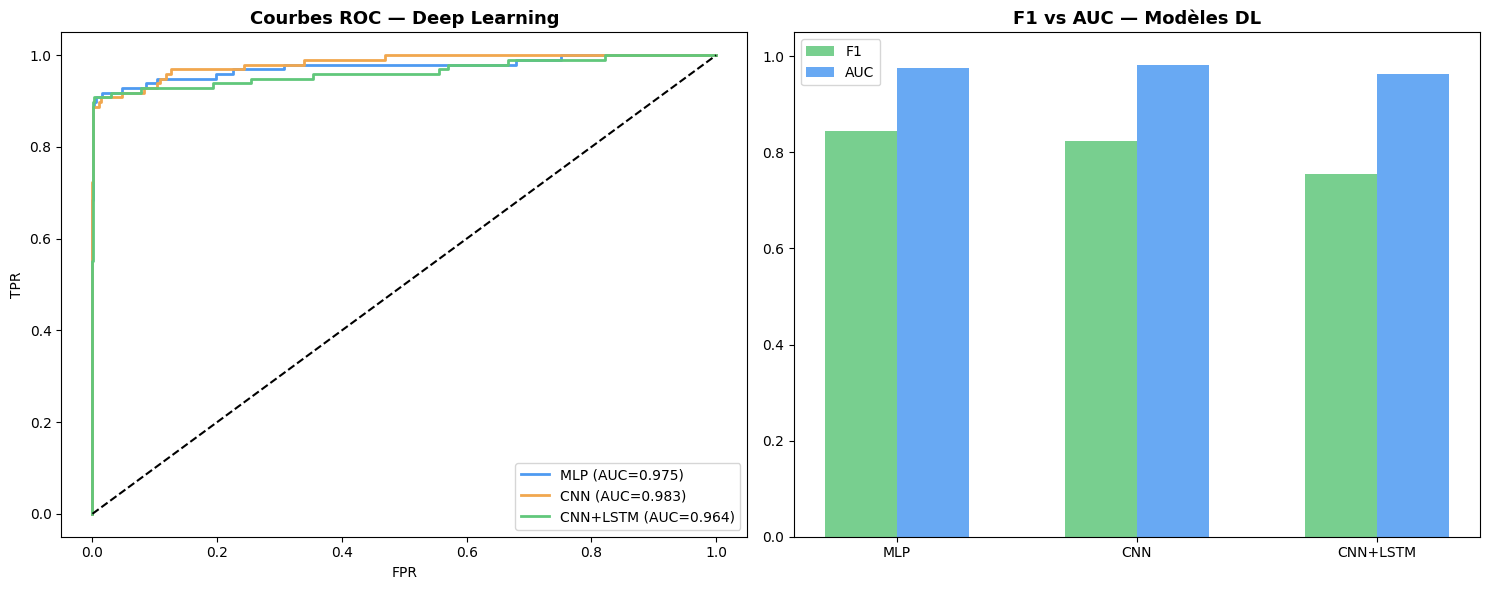

In [10]:
if results_dl:
    df_dl = pd.DataFrame(results_dl)
    print("\n📊 TABLEAU DES MODÈLES DEEP LEARNING")
    display(df_dl.style
            .highlight_max(subset=['F1','AUC','Rappel'], color='#c8e6c9')
            .format({c: '{:.4f}' for c in ['Précision','Rappel','F1','AUC','AUPRC']}))

    # Courbes ROC comparées
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    colors = ['#4e9af1', '#f1a74e', '#61c77b']
    for (name, (y_true, y_prob)), color in zip(roc_data_dl.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
    axes[0].plot([0,1],[0,1],'k--')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('Courbes ROC — Deep Learning', fontsize=13, fontweight='bold')
    axes[0].legend()

    # Comparaison F1 / AUC
    models_dl = [r['Modèle'] for r in results_dl]
    x = np.arange(len(models_dl))
    w = 0.3
    axes[1].bar(x - w/2, [r['F1']  for r in results_dl], w, label='F1',  color='#61c77b', alpha=0.85)
    axes[1].bar(x + w/2, [r['AUC'] for r in results_dl], w, label='AUC', color='#4e9af1', alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(models_dl)
    axes[1].set_ylim(0, 1.05); axes[1].legend()
    axes[1].set_title('F1 vs AUC — Modèles DL', fontsize=13, fontweight='bold')

    plt.tight_layout(); plt.show()


## ✅ Résumé
- **MLP** : réseau feedforward simple, interprétable
- **CNN** : détecte des patterns locaux dans les features PCA
- **CNN+LSTM** : combine extraction locale + séquentielle (meilleure performance)